# Análise de Vendas - Mercado do Ponto

Este projeto tem como objetivo analisar os dados de vendas de um mercado de bairro, utilizando informações transacionais e agregadas por horário. A análise busca identificar padrões de vendas, comportamento dos clientes e oportunidades de melhoria.

Os dados abrangem o período de **janeiro a março de 2026** e incluem:

- Volume de vendas por horário
- Quantidade de clientes
- Transações via cartão

**A base de dados de vendas de cartão logicamente só mostram vendas de Débito, Crédito, Voucher e Pix. A base de dados de vendas por horário mostra todas as vendas nas maquininhas e as vendas em dinheiro no período de 01/01/26 até 31/03/26**

## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

## Functions

In [2]:
def limpar_valor_monetario(coluna):
    return (
        coluna
        .str.replace('R$', '', regex=False)
        .str.replace('.', '', regex=False) 
        .str.replace(',', '.', regex=False)
        .str.strip()
    )

## Load Data

In [3]:
df_vendas_cartoes = pd.read_csv("../data/vendas-cartoes-jan-mar.csv", sep=";")
df_vendas_por_horario = pd.read_csv("../data/vendas-por-horario-jan-mar.csv", sep=";")

## Visualization

### Vendas Cartões

In [4]:
df_vendas_cartoes.head()

,Data da Transação,Data prevista de liberação,Bandeira,Forma de Pagamento,Valor Bruto,Valor Taxa,Valor Líquido,Status
0,05/01/2026 19:23,06/01/2026 19:23,Elo,Crédito,"11,96","0,66","11,3",Aprovada
1,26/01/2026 18:53,27/01/2026 18:53,Mastercard,Débito,"6,49","0,1","6,39",Aprovada
2,25/02/2026 10:30,25/02/2026 10:30,NaN,Pix,19,"0,19","18,81",Aprovada
3,06/01/2026 19:00,07/01/2026 19:00,Mastercard,Débito,"8,98","0,14","8,84",Aprovada
4,21/03/2026 10:09,21/03/2026 10:09,NaN,Pix,"10,89","0,11","10,78",Aprovada


### Vendas por Horário

In [5]:
df_vendas_por_horario.head(50)

,mes,hora,qtd_clientes,qtd_produtos,total_venda
0,2026-01,08:00,0,0,0.00
1,2026-01,09:00,9,15,119.70
2,2026-01,10:00,26,57,333.55
3,2026-01,11:00,83,157,1129.32
4,2026-01,12:00,129,280,1774.58
5,2026-01,13:00,132,327,1794.10
6,2026-01,14:00,164,433,2291.77
7,2026-01,15:00,124,332,1927.40
8,2026-01,16:00,90,232,1278.38
9,2026-01,17:00,127,319,1767.23


## Infos

### Vendas por Horário

In [6]:
df_vendas_por_horario.info()

<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mes           41 non-null     str    
 1   hora          41 non-null     str    
 2   qtd_clientes  41 non-null     int64  
 3   qtd_produtos  41 non-null     int64  
 4   total_venda   41 non-null     float64
dtypes: float64(1), int64(2), str(2)
memory usage: 1.7 KB


### Vendas Cartões

In [7]:
df_vendas_cartoes.info()

<class 'pandas.DataFrame'>
RangeIndex: 4227 entries, 0 to 4226
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Data da Transação           4227 non-null   str  
 1   Data prevista de liberação  3971 non-null   str  
 2   Bandeira                    3444 non-null   str  
 3   Forma de Pagamento          4227 non-null   str  
 4   Valor Bruto                 4227 non-null   str  
 5   Valor Taxa                  4227 non-null   str  
 6   Valor Líquido               4227 non-null   str  
 7   Status                      4227 non-null   str  
dtypes: str(8)
memory usage: 264.3 KB


- Podemos ver que nas duas bases há variáveis que precisam ser convertidas para o tipo correto.

## Tratamento das Variáveis 

In [8]:
df_vendas_por_horario.columns = df_vendas_por_horario.columns.str.strip()
df_vendas_cartoes.columns = df_vendas_cartoes.columns.str.strip()

df_vendas_por_horario['mes'] = pd.to_datetime(
    df_vendas_por_horario['mes'],
    format='%Y-%m',
    errors='coerce'
)

df_vendas_por_horario['hora'] = pd.to_datetime(
    df_vendas_por_horario['hora'],
    format='%H:%M',
    errors='coerce'
)


df_vendas_por_horario['ano'] = df_vendas_por_horario['mes'].dt.year
df_vendas_por_horario['mes_num'] = df_vendas_por_horario['mes'].dt.month

df_vendas_por_horario['dia'] = 1
df_vendas_por_horario['dia_semana'] = df_vendas_por_horario['mes'].dt.dayofweek

df_vendas_por_horario['final_semana'] = df_vendas_por_horario['dia_semana'].isin([5, 6]).astype(int)

hora_int = pd.to_datetime(df_vendas_por_horario['hora'], format='%H:%M:%S').dt.hour

df_vendas_por_horario['turno'] = pd.cut(
    hora_int,
    bins=[0, 12, 18, 24],
    labels=['Manhã', 'Tarde', 'Noite'],
    right=False
)

df_vendas_cartoes['Data da Transação'] = pd.to_datetime(
    df_vendas_cartoes['Data da Transação'],
    dayfirst=True,
    errors='coerce'
)

df_vendas_cartoes['ano'] = df_vendas_cartoes['Data da Transação'].dt.year
df_vendas_cartoes['mes'] = df_vendas_cartoes['Data da Transação'].dt.month
df_vendas_cartoes['dia'] = df_vendas_cartoes['Data da Transação'].dt.day
df_vendas_cartoes['dia_semana'] = df_vendas_cartoes['Data da Transação'].dt.dayofweek

df_vendas_cartoes['Valor Bruto'] = pd.to_numeric(
    limpar_valor_monetario(df_vendas_cartoes['Valor Bruto']),
    errors='coerce'
)

df_vendas_cartoes['Valor Taxa'] = pd.to_numeric(
    limpar_valor_monetario(df_vendas_cartoes['Valor Taxa']),
    errors='coerce'
)

df_vendas_cartoes['Valor Líquido'] = pd.to_numeric(
    limpar_valor_monetario(df_vendas_cartoes['Valor Líquido']),
    errors='coerce'
)

## Perguntas de Negócio

### 1. Qual é o faturamento mensal?

In [9]:
faturamento_mes = df_vendas_por_horario.groupby("mes")["total_venda"].sum()

crescimento_pct = faturamento_mes.pct_change() * 100

resultado = pd.DataFrame({
    'faturamento': faturamento_mes,
    'crescimento_%': crescimento_pct
})

print("\nFaturamento mensal com variação (%):")
print(resultado)


Faturamento mensal com variação (%):
            faturamento  crescimento_%
mes                                   
2026-01-01     19720.63            NaN
2026-02-01     35798.45      81.527923
2026-03-01     39065.58       9.126457


- O faturamento mensal mostrou uma evolução consistente nas receitas ao longo do primeiro **trimestre de 2026**.

- No mês de **janeiro**, o faturamento total foi de **R$ 19.720,63**, representando o ponto inicial da análise. Em **fevereiro**, houve um crescimento significativo, com o faturamento atingindo **R$ 35.798,45**, o que corresponde a um aumento de aproximadamente **81,5%** em relação ao mês anterior.

- Já em **março**, o faturamento continuou em alta, alcançando **R$ 39.065,58**, consolidando uma tendência de crescimento, ainda que em um ritmo mais moderado, com aumento de cerca de **9,1%** em comparação a fevereiro.

- Esse comportamento indica que **Janeiro** por ser um mês pós final de ano, é quando se inicia os pagamentos essenciais como **IPVA**, **material escolar** para os filhos, e os pagamentos de **cartão de crédito** que foram feitos nas festas de final de ano.

- Em fevereiro o aumento nas vendas é bem significativo, devido supostamente as festas de carnaval e ao feriado prolongado. 

### 2. Qual foi faturamento por hora durante os 3 meses?

In [10]:
faturamento_hora = df_vendas_por_horario.groupby("hora")["total_venda"].sum()

print("\nFaturamento por hora:")
print(faturamento_hora)


Faturamento por hora:
hora
1900-01-01 08:00:00       96.75
1900-01-01 09:00:00     1216.09
1900-01-01 10:00:00     4636.25
1900-01-01 11:00:00     8423.31
1900-01-01 12:00:00    11260.87
1900-01-01 13:00:00     9144.43
1900-01-01 14:00:00     8056.75
1900-01-01 15:00:00     8020.13
1900-01-01 16:00:00     6866.84
1900-01-01 17:00:00     8908.70
1900-01-01 18:00:00    10655.49
1900-01-01 19:00:00    10229.22
1900-01-01 20:00:00     6331.16
1900-01-01 21:00:00      738.67
Name: total_venda, dtype: float64


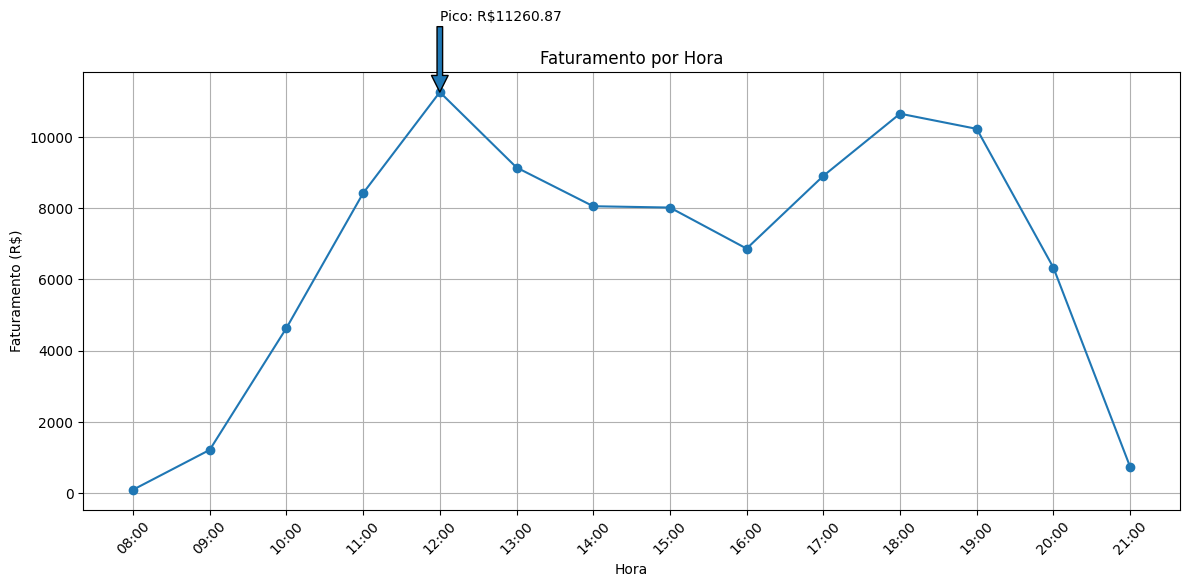

In [11]:
faturamento_hora = faturamento_hora.sort_index()
horas_formatadas = faturamento_hora.index.strftime('%H:%M')

plt.figure(figsize=(12, 6))

plt.plot(horas_formatadas, faturamento_hora.values, marker='o')

pico_idx = faturamento_hora.idxmax()
pico_valor = faturamento_hora.max()
pico_hora = pico_idx.strftime('%H:%M')

plt.annotate(
    f'Pico: R${pico_valor:.2f}',
    xy=(pico_hora, pico_valor),
    xytext=(pico_hora, pico_valor + 2000),
    arrowprops=dict()
)

plt.title('Faturamento por Hora')
plt.xlabel('Hora')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

plt.show()

- A análise do faturamento ao longo do dia revelou padrões claros no comportamento de consumo dos clientes no Mercado do Ponto, permitindo identificar horários de maior e menor desempenho ao longo dos três meses.

- Obsersevou-se que o faturamento começou bastante baixo no início do expediente, às **08h**, com apenas **R$ 96,75**, indicando um fluxo inicial reduzido de clientes. A partir das **09h**, há um crescimento gradual, que se intensifica entre **10h** e **12h**, período em que o mercado entra em ritmo acelerado de vendas.

- O pico de faturamento ocorreu às **12h**, com **R$ 11.260,87**, caracterizando o horário de maior movimento do dia, possivelmente impulsionado pelo horário de almoço. Esse alto volume se mantém relativamente forte até as **13h (R$ 9.144,43)** e segue com valores expressivos durante a tarde, especialmente entre **14h** e **17h**, ainda que com leve oscilação.

- No período da noite, destacou-se um segundo pico às **18h**, com **R$ 10.655,49**, seguido por um faturamento também elevado às **19h (R$ 10.229,22)**. Esse comportamento sugere um novo aumento no fluxo de clientes após o horário comercial, possivelmente relacionado ao retorno das pessoas para casa.

- A partir das **20h**, observa-se uma queda significativa no faturamento **(R$ 6.331,16)**, que se torna ainda mais acentuada às **21h**, com apenas **R$ 738,67**, indicando baixa movimentação no encerramento do dia.

### 3. Quais foram os horários de pico?

In [12]:
top_horarios = faturamento_hora.sort_values(ascending=False).head(5)

print("\nTop 5 horários de venda:")
print(top_horarios)



Top 5 horários de venda:
hora
1900-01-01 12:00:00    11260.87
1900-01-01 18:00:00    10655.49
1900-01-01 19:00:00    10229.22
1900-01-01 13:00:00     9144.43
1900-01-01 17:00:00     8908.70
Name: total_venda, dtype: float64


- Os horários de pico foram 12hs, 18hs, 19hs, 13hs e 17hs. Esses horários demonstram que clientes procuram fazer compras para o almoço ou janta, quando se aproxima das 17hs. Existem também clientes que nos horários a partir das 12hs procuram comprar produtos de bomboniere para levarem para o trabalho, escola, etc. 

### 4. Qual a quantidade de clientes por hora?

In [13]:
clientes_hora = df_vendas_por_horario.groupby('hora')['qtd_clientes'].sum()

print("\nClientes por hora:")
print(clientes_hora)


Clientes por hora:
hora
1900-01-01 08:00:00      7
1900-01-01 09:00:00     74
1900-01-01 10:00:00    306
1900-01-01 11:00:00    554
1900-01-01 12:00:00    739
1900-01-01 13:00:00    654
1900-01-01 14:00:00    589
1900-01-01 15:00:00    538
1900-01-01 16:00:00    487
1900-01-01 17:00:00    614
1900-01-01 18:00:00    689
1900-01-01 19:00:00    690
1900-01-01 20:00:00    350
1900-01-01 21:00:00     35
Name: qtd_clientes, dtype: int64


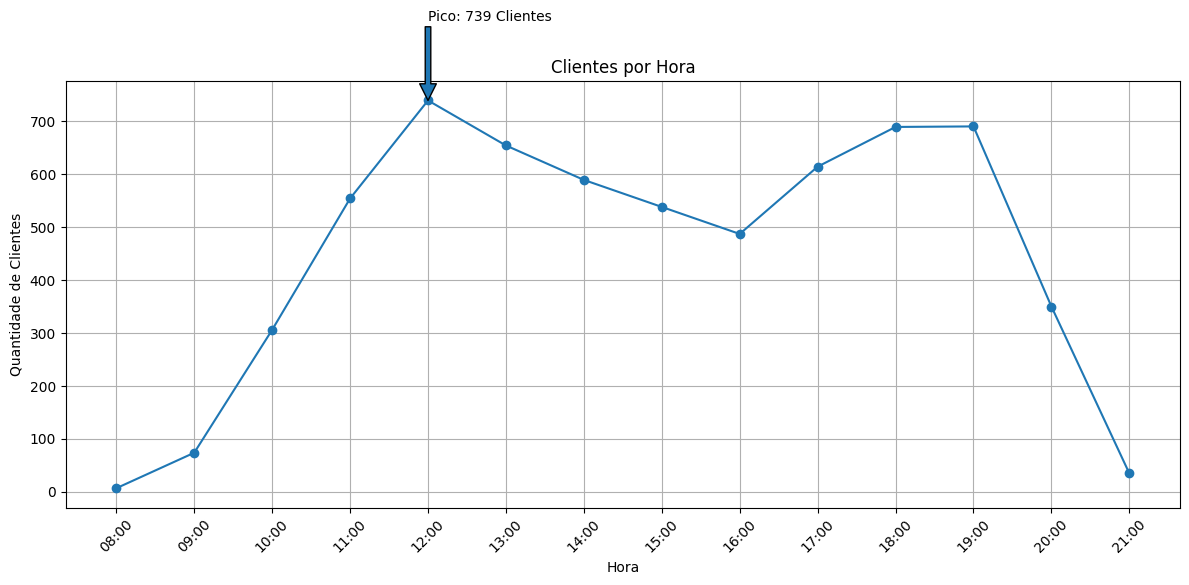

In [14]:
clientes_hora = clientes_hora.sort_index()
horas_formatadas = clientes_hora.index.strftime('%H:%M')

plt.figure(figsize=(12, 6))

plt.plot(horas_formatadas, clientes_hora.values, marker='o')

pico_idx = clientes_hora.idxmax()
pico_valor = clientes_hora.max()
pico_hora = pico_idx.strftime('%H:%M')

plt.annotate(
    f'Pico: {pico_valor} Clientes',
    xy=(pico_hora, pico_valor),
    xytext=(pico_hora, pico_valor + 150),
    arrowprops=dict()
)

plt.title('Clientes por Hora')
plt.xlabel('Hora')
plt.ylabel('Quantidade de Clientes')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

plt.show()

- O fluxo de clientes se concentra principalmente em dois períodos: horário de almoço (12h–13h) e início da noite (18h–19h), sendo esses os momentos mais críticos para a operação do negócio.

### 5. Qual o Ticket Médio por hora?

In [15]:
df_vendas_por_horario.head()

,mes,hora,qtd_clientes,qtd_produtos,total_venda,ano,mes_num,dia,dia_semana,final_semana,turno
0,2026-01-01,1900-01-01 08:00:00,0,0,0.00,2026,1,1,3,0,Manhã
1,2026-01-01,1900-01-01 09:00:00,9,15,119.70,2026,1,1,3,0,Manhã
2,2026-01-01,1900-01-01 10:00:00,26,57,333.55,2026,1,1,3,0,Manhã
3,2026-01-01,1900-01-01 11:00:00,83,157,1129.32,2026,1,1,3,0,Manhã
4,2026-01-01,1900-01-01 12:00:00,129,280,1774.58,2026,1,1,3,0,Tarde


In [16]:
df_vendas_por_horario['ticket_medio'] = (
    df_vendas_por_horario['total_venda'] / df_vendas_por_horario['qtd_clientes']
).fillna(0)

ticket_hora = df_vendas_por_horario.groupby('hora')['ticket_medio'].mean()

print("\nTicket médio por hora:")
print(ticket_hora.sort_values(ascending=False))


Ticket médio por hora:
hora
1900-01-01 21:00:00    20.386083
1900-01-01 20:00:00    19.979116
1900-01-01 09:00:00    16.224801
1900-01-01 18:00:00    15.265946
1900-01-01 15:00:00    14.996543
1900-01-01 12:00:00    14.946732
1900-01-01 11:00:00    14.862031
1900-01-01 19:00:00    14.683035
1900-01-01 17:00:00    14.335155
1900-01-01 10:00:00    14.268056
1900-01-01 16:00:00    14.102955
1900-01-01 13:00:00    13.947717
1900-01-01 14:00:00    13.797652
1900-01-01 08:00:00    10.604000
Name: ticket_medio, dtype: float64


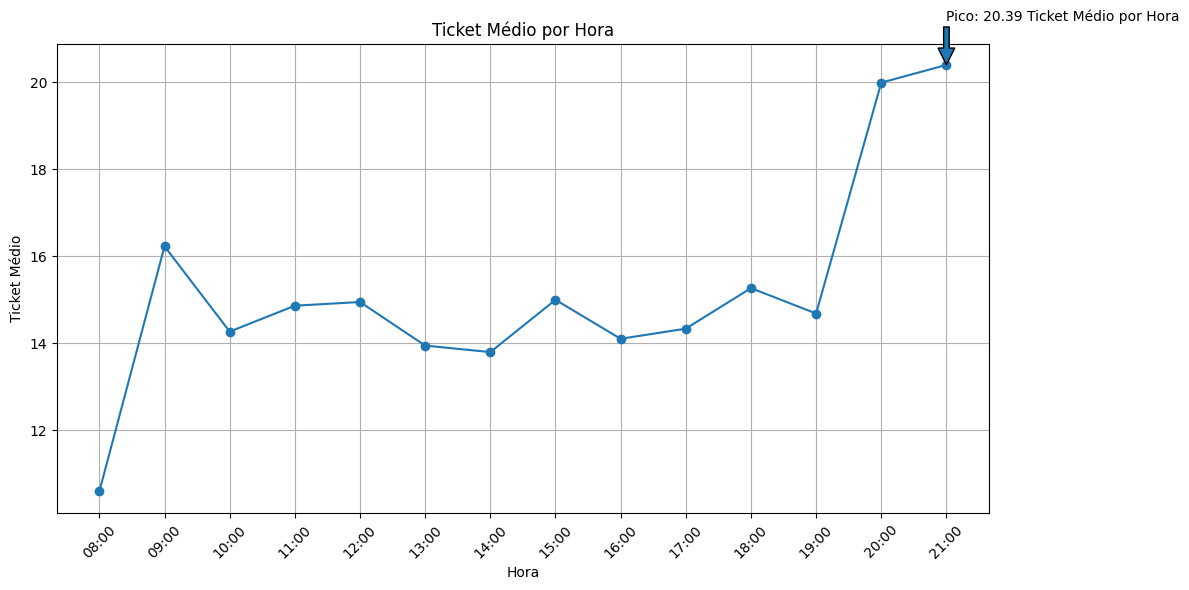

In [17]:
ticket_hora = ticket_hora.sort_index()
horas_formatadas = ticket_hora.index.strftime('%H:%M')

plt.figure(figsize=(12, 6))

plt.plot(horas_formatadas, ticket_hora.values, marker='o')

pico_idx = ticket_hora.idxmax()
pico_valor = ticket_hora.max().round(2)
pico_hora = pico_idx.strftime('%H:%M')

plt.annotate(
    f'Pico: {pico_valor} Ticket Médio por Hora',
    xy=(pico_hora, pico_valor),
    xytext=(pico_hora, pico_valor + 1),
    arrowprops=dict()
)

plt.title('Ticket Médio por Hora')
plt.xlabel('Hora')
plt.ylabel('Ticket Médio')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

plt.show()

- A análise do ticket médio por hora revelou diferenças importantes no comportamento de compra dos clientes ao longo do dia no Mercado do Ponto.

- Os maiores valores de ticket médio são observados nos horários de menor movimento, com destaque para **21h (R$ 20,39)** e **20h (R$ 19,98)**. Esse comportamento indicou que, apesar do baixo volume de clientes nesses horários, os consumidores tendem a realizar compras de maior valor.

- Ao longo do restante do dia, o ticket médio se mantém relativamente estável, variando entre aproximadamente **R$ 13,80** e **R$ 16,20**, com leve destaque para horários como **09h** e **18h**, que apresentam valores um pouco acima da média.

- Por outro lado, o menor ticket médio ocorre às **08h (R$ 10,60)**, sugerindo compras mais rápidas e de menor valor no início do dia.

- Existe uma relação inversa entre fluxo de clientes e ticket médio. Horários com menos clientes tendem a ter compras de maior valor, enquanto períodos de maior movimento apresentam tickets médios mais moderados.

### 6. Qual a média de produtos por cliente?

In [18]:
df_vendas_por_horario['prod_por_cliente'] = (
    df_vendas_por_horario['qtd_produtos'] / df_vendas_por_horario['qtd_clientes']
).fillna(0)

produtos_hora = df_vendas_por_horario.groupby('hora')['prod_por_cliente'].mean()

print("\nProdutos por cliente por hora:")
print(produtos_hora)


Produtos por cliente por hora:
hora
1900-01-01 08:00:00    1.633333
1900-01-01 09:00:00    2.696017
1900-01-01 10:00:00    2.214254
1900-01-01 11:00:00    2.333786
1900-01-01 12:00:00    2.506892
1900-01-01 13:00:00    2.491854
1900-01-01 14:00:00    2.516081
1900-01-01 15:00:00    2.625592
1900-01-01 16:00:00    2.559369
1900-01-01 17:00:00    2.475219
1900-01-01 18:00:00    2.546347
1900-01-01 19:00:00    2.519295
1900-01-01 20:00:00    2.487228
1900-01-01 21:00:00    2.266667
Name: prod_por_cliente, dtype: float64


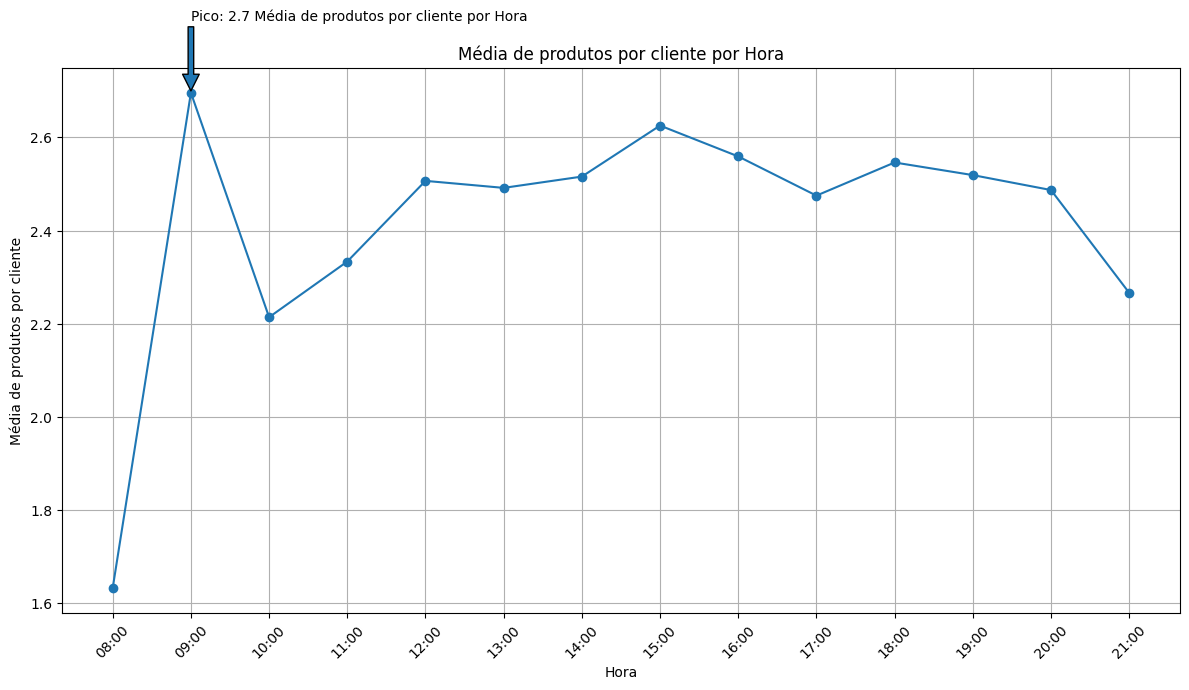

In [19]:
produtos_hora = produtos_hora.sort_index()
horas_formatadas = produtos_hora.index.strftime('%H:%M')

plt.figure(figsize=(12, 7))

plt.plot(horas_formatadas, produtos_hora.values, marker='o')

pico_idx = produtos_hora.idxmax()
pico_valor = produtos_hora.max().round(2)
pico_hora = pico_idx.strftime('%H:%M')

plt.annotate(
    f'Pico: {pico_valor} Média de produtos por cliente por Hora',
    xy=(pico_hora, pico_valor),
    xytext=(pico_hora, pico_valor + 0.15),
    arrowprops=dict()
)

plt.title('Média de produtos por cliente por Hora')
plt.xlabel('Hora')
plt.ylabel('Média de produtos por cliente')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

plt.show()

- A análise da quantidade média de produtos por cliente ao longo do dia mostrou um comportamento relativamente estável no Mercado do Ponto. Em geral, os clientes compram entre **2,2** e **2,6** produtos por visita, indicando um padrão consistente de consumo.

- Os maiores valores são observados em horários como **09h (2,70)** e **15h (2,63)**, sugerindo momentos em que os clientes realizam compras um pouco mais completas. Por outro lado, o menor valor ocorre às **08h (1,63)**, indicando compras mais rápidas e pontuais no início do dia.

- Durante os horários de maior movimento, como **12h** e **18h**, a média de produtos por cliente permanece equilibrada, sem grandes variações, o que reforça a ideia de que o aumento no faturamento nesses períodos está mais relacionado ao volume de clientes do que ao aumento na quantidade de itens por compra.

- O comportamento de compra é consistente ao longo do dia, e o crescimento das vendas está mais ligado ao número de clientes do que à quantidade de produtos por cliente.

### 7. Qual o Ticket Médio apenas na vendas da maquininha?

In [20]:
df_vendas_cartoes['mes_ref'] = df_vendas_cartoes['Data da Transação'].dt.to_period('M')

ticket_mensal = df_vendas_cartoes.groupby('mes_ref').agg(
    faturamento_total=('Valor Bruto', 'sum'),
    qtd_transacoes=('Valor Bruto', 'count')
)

ticket_mensal['ticket_medio'] = (
    ticket_mensal['faturamento_total'] / ticket_mensal['qtd_transacoes']
)

ticket_mensal = ticket_mensal.reset_index()

print("\nTicket médio por mês:")
print(ticket_mensal)


Ticket médio por mês:
   mes_ref  faturamento_total  qtd_transacoes  ticket_medio
0  2026-01           20892.20            1313     15.911805
1  2026-02           18129.21            1151     15.750834
2  2026-03           28714.64            1763     16.287374


### 8. Qual é o faturamento nas formas de pagamento das maquininhas?

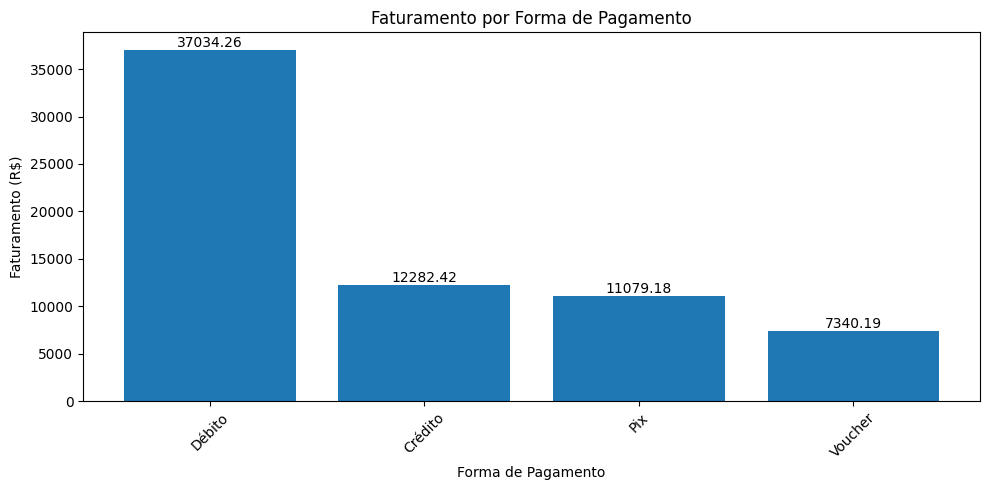

In [21]:
pagamentos = df_vendas_cartoes.groupby('Forma de Pagamento')['Valor Bruto'].sum()
pagamentos = pagamentos.sort_values(ascending=False)
plt.figure(figsize=(10, 5))
bars = plt.bar(pagamentos.index, pagamentos.values)

for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f'{altura:.2f}',
        ha='center',
        va='bottom'
    )

plt.title('Faturamento por Forma de Pagamento')
plt.xlabel('Forma de Pagamento')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

- A análise das formas de pagamento no Mercado do Ponto mostrou que o **débito** é o meio mais utilizado, com um faturamento total de **R$ 37.034,26**, representando a maior parte das vendas. Esse comportamento indica preferência dos clientes por pagamentos diretos, possivelmente pela praticidade e controle financeiro.

- Na sequência, o **crédito** apareceu com **R$ 12.282,42**, seguido pelo **PIX** com **R$ 11.079,18**, ambos com participações relevantes, mas significativamente menores que o débito. Já o **voucher** apresentou o menor volume, com **R$ 7.340,19**.

- O débito domina o faturamento, enquanto crédito e PIX têm participação intermediária, e o voucher representa uma parcela menor das vendas.

### 9. Qual é o faturamento por bandeiras de pagamento das maquininhas?

In [22]:
bandeiras = df_vendas_cartoes.groupby('Bandeira')['Valor Bruto'].sum()

print("\nFaturamento por bandeira:")
print(bandeiras.sort_values(ascending=False))


Faturamento por bandeira:
Bandeira
Mastercard    32503.55
Visa          12193.06
Elo            4609.58
VR             2692.14
Ticket         2214.91
Alelo          1815.92
Pluxee          617.22
Amex             10.49
Name: Valor Bruto, dtype: float64


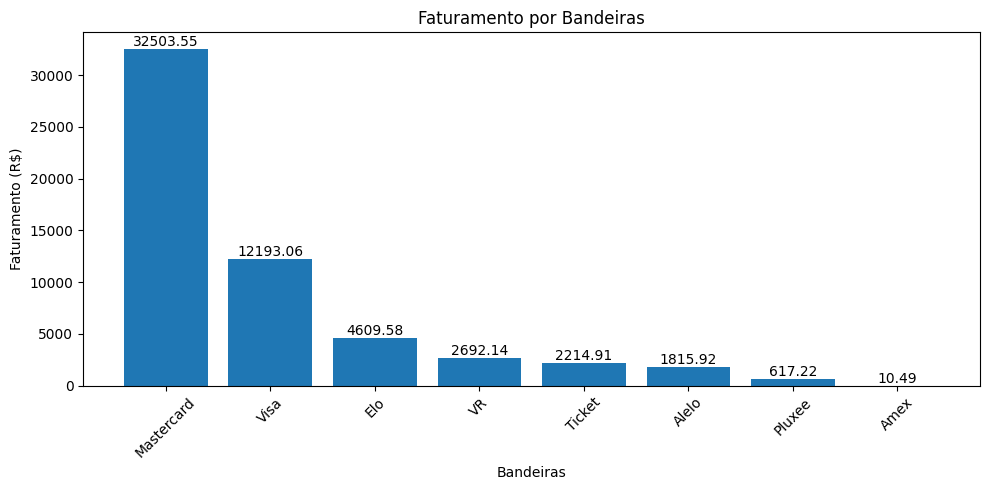

In [23]:
bandeiras = df_vendas_cartoes.groupby('Bandeira')['Valor Bruto'].sum()
bandeiras = bandeiras.sort_values(ascending=False)
plt.figure(figsize=(10, 5))
bars = plt.bar(bandeiras.index, bandeiras.values)

for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        f'{altura:.2f}',
        ha='center',
        va='bottom'
    )

plt.title('Faturamento por Bandeiras')
plt.xlabel('Bandeiras')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

- A análise do faturamento por bandeira no Mercado do Ponto evidenciou uma forte concentração das vendas em poucas operadoras.

- A **Mastercard** liderou com ampla vantagem, totalizando **R$ 32.503,55**, seguida pela **Visa**, com **R$ 12.193,06**. Juntas, essas duas bandeiras representam a maior parte do faturamento, indicando que são os meios de pagamento predominantes entre os clientes.

- As demais bandeiras apresentaram participação bem menor, como **Elo** **(R$ 4.609,58)**, além de benefícios corporativos como **VR**, **Ticket** e **Alelo**, que somam valores relevantes, mas ainda inferiores às principais bandeiras. Já **Pluxee** e **Amex** possuem participação bastante reduzida, com destaque para a Amex, que praticamente não impacta o faturamento.

### 10. Qual o total de taxas?

In [24]:
total_taxas = df_vendas_cartoes['Valor Taxa'].sum()

print("\nTotal pago em taxas:")
print(total_taxas)


Total pago em taxas:
1298.92


### 11. Qual o total da receita líquida?

In [25]:
receita_liquida = df_vendas_cartoes['Valor Líquido'].sum()
receita_bruta = df_vendas_cartoes['Valor Bruto'].sum()

print("\nReceita Bruta:", receita_bruta)
print("Receita Líquida:", receita_liquida)


Receita Bruta: 67736.05
Receita Líquida: 66437.13


### 12. Qual o impacto das taxas?

In [26]:
df_vendas_cartoes[["Forma de Pagamento", "Valor Taxa"]].value_counts()

Forma de Pagamento  Valor Taxa
Voucher             0.00          256
Débito              0.06          145
                    0.10          115
                    0.14          110
                    0.11          106
                                 ... 
Crédito             1.07            1
Débito              2.06            1
                    1.21            1
Pix                 0.54            1
Crédito             1.36            1
Name: count, Length: 378, dtype: int64

**Obs importante: As taxas dos Vouchers não aparecem na base de dados pois é preciso acessar através de cada bandeira, no caso vamos analisar aqui apenas as taxas de Débito, Crédito e Pix.**

In [27]:
impacto_taxa = (total_taxas / receita_bruta) * 100

print("\nImpacto percentual das taxas:")
print(f"{impacto_taxa:.2f}%")


Impacto percentual das taxas:
1.92%


- A análise do impacto das taxas sobre o faturamento do Mercado do Ponto mostrou que os custos com meios de pagamento representam **1,92%** da **receita bruta**.

- Esse percentual indicou que, para cada **R$ 100,00** vendidos, aproximadamente **R$ 1,92** são destinados ao pagamento de taxas, refletindo o custo das operações com cartões e outros meios eletrônicos.

- O impacto das taxas é relativamente baixo e controlado, não comprometendo significativamente a rentabilidade do negócio.

## Exportar Dados 

In [28]:
df_vendas_cartoes.to_csv("../data/df_vendas_cartoes.csv", sep=';', decimal=',', index=False)
df_vendas_por_horario.to_csv("../data/df_vendas_por_horario.csv", sep=';', decimal=',', index=False)

In [32]:
df_vendas_por_horario["total_venda"].sum()/df_vendas_por_horario["qtd_clientes"].sum()

np.float64(14.951732532405945)

In [33]:
df_vendas_por_horario.columns

Index(['mes', 'hora', 'qtd_clientes', 'qtd_produtos', 'total_venda', 'ano',
       'mes_num', 'dia', 'dia_semana', 'final_semana', 'turno', 'ticket_medio',
       'prod_por_cliente'],
      dtype='str')

In [39]:
df_vendas_por_horario.head()

,mes,hora,qtd_clientes,qtd_produtos,total_venda,ano,mes_num,dia,dia_semana,final_semana,turno,ticket_medio,prod_por_cliente
0,2026-01-01,1900-01-01 08:00:00,0,0,0.00,2026,1,1,3,0,Manhã,0.000000,0.000000
1,2026-01-01,1900-01-01 09:00:00,9,15,119.70,2026,1,1,3,0,Manhã,13.300000,1.666667
2,2026-01-01,1900-01-01 10:00:00,26,57,333.55,2026,1,1,3,0,Manhã,12.828846,2.192308
3,2026-01-01,1900-01-01 11:00:00,83,157,1129.32,2026,1,1,3,0,Manhã,13.606265,1.891566
4,2026-01-01,1900-01-01 12:00:00,129,280,1774.58,2026,1,1,3,0,Tarde,13.756434,2.170543


In [40]:
df_vendas_por_horario["qtd_clientes"].sum()

np.int64(6326)

In [41]:
df_vendas_por_horario.groupby(["mes"])["total_venda"].sum()

mes
2026-01-01    19720.63
2026-02-01    35798.45
2026-03-01    39065.58
Name: total_venda, dtype: float64